## Load and inspect the data

In [4]:
import json
import pandas as pd
import numpy as np
from pandas import json_normalize
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

try:
    with open("bookworms_dataset.json", "r") as file:
        data = json.load(file)
except FileNotFoundError:
    print("error opening file")
except json.JSONDecodeError:
    print("error decoding json file")

books = pd.DataFrame(data["books"])
bookworms = pd.DataFrame(data["bookworms"])

# flattened version
bookworms_full = json_normalize(data["bookworms"])
bookworms_full.head(5)

,user_id,name,age,member_since,books_read,wishlist,location.city,location.country,location.timezone,preferences.favorite_genres,...,preferences.preferred_moods,preferences.preferred_length,preferences.preferred_era,reading_stats.total_books_read,reading_stats.reading_goal_per_year,reading_stats.books_read_this_year,reading_stats.avg_rating_given,reading_stats.longest_streak_days,reading_stats.most_read_genre,reading_stats.most_read_author_id
0,u001,Fadi,29,2021-03-15,"[{'book_id': 'b001', 'rating': 5, 'date_read':...","[{'book_id': 'b014', 'added_date': '2022-06-01...",Beirut,Lebanon,Asia/Beirut,"[dystopia, feminist, fiction]",...,"[dark, cerebral]",medium,"[modern, contemporary]",2,24,7,4.50,21,dystopia,a001
1,u002,Peggy,34,2020-07-01,"[{'book_id': 'b002', 'rating': 4, 'date_read':...","[{'book_id': 'b012', 'added_date': '2022-03-01...",Dublin,Ireland,Europe/Dublin,"[classic, romance, dystopia]",...,"[romantic, contemplative, dark]",long,"[classic, modern]",3,30,12,4.67,45,classic,a001
2,u003,Amara,26,2022-01-20,"[{'book_id': 'b023', 'rating': 5, 'date_read':...","[{'book_id': 'b047', 'added_date': '2022-10-01...",Lagos,Nigeria,Africa/Lagos,"[fiction, historical, feminist]",...,"[uplifting, cerebral]",medium,"[modern, contemporary]",4,20,5,4.50,14,fiction,a015
3,u004,Soren,41,2019-11-11,"[{'book_id': 'b005', 'rating': 5, 'date_read':...","[{'book_id': 'b042', 'added_date': '2022-05-01...",Copenhagen,Denmark,Europe/Copenhagen,"[sci-fi, dystopia, classic]",...,"[dark, adventurous, cerebral]",any,"[classic, modern]",6,40,18,4.33,90,dystopia,a004
4,u005,Lena,31,2021-06-30,"[{'book_id': 'b033', 'rating': 5, 'date_read':...","[{'book_id': 'b030', 'added_date': '2022-11-01...",Berlin,Germany,Europe/Berlin,"[fiction, drama, mental-health]",...,"[dark, contemplative]",long,"[modern, classic]",5,15,6,4.20,30,fiction,a019


In [15]:
print("Books shape:", books.shape)
print("Bookworms shape:", bookworms.shape)
print("\nBooks columns:", books.columns.tolist())
print("\nBookworms columns:", bookworms_full.columns.tolist())

Books shape: (50, 10)
Bookworms shape: (15, 9)

Books columns: ['book_id', 'title', 'author', 'author_id', 'genres', 'year', 'pages', 'avg_rating', 'language', 'isbn']

Bookworms columns: ['user_id', 'name', 'age', 'member_since', 'books_read', 'wishlist', 'location.city', 'location.country', 'location.timezone', 'preferences.favorite_genres', 'preferences.disliked_genres', 'preferences.favorite_authors', 'preferences.reading_pace', 'preferences.preferred_moods', 'preferences.preferred_length', 'preferences.preferred_era', 'reading_stats.total_books_read', 'reading_stats.reading_goal_per_year', 'reading_stats.books_read_this_year', 'reading_stats.avg_rating_given', 'reading_stats.longest_streak_days', 'reading_stats.most_read_genre', 'reading_stats.most_read_author_id']


## Flatten Ratings into an interactions table

In [43]:
ratings_rows = []

for user in data["bookworms"]:
    for entry in user["books_read"]:
        ratings_rows.append({
            "user_id": user["user_id"],
            "user_name": user["name"],
            "book_id": entry["book_id"],
            "rating": entry["rating"],
            "reread":  entry["reread"], # strong positive signal
            "dnf": entry["did_not_finish"], # strong negative signal
            "date_read": entry["date_read"]
        })

ratings = pd.DataFrame(ratings_rows)

# boost reread ratings slightly - reread means they really loved it
ratings["adjusted_rating"] = ratings.apply(
    lambda row: min(row["rating"] + 0.5, 5.0) if row["reread"] else row["rating"], axis=1
)

# penalize did-not-finish
ratings["adjusted_rating"] = ratings.apply(
    lambda row: max(row["adjusted_rating"] - 1.0, 1.0) if row["dnf"] else row["adjusted_rating"], axis=1
)

print(f"Total ratings: {len(ratings)}\n")
ratings.head(10)

Total ratings: 78



,user_id,user_name,book_id,rating,reread,dnf,date_read,adjusted_rating
0,u001,Fadi,b001,5,False,False,2022-01-10,5.0
1,u001,Fadi,b003,4,False,False,2022-04-22,4.0
2,u002,Peggy,b002,4,False,False,2021-06-05,4.0
3,u002,Peggy,b001,5,True,False,2021-08-18,5.0
4,u002,Peggy,b004,5,True,False,2022-02-14,5.0
5,u003,Amara,b023,5,False,False,2022-03-01,5.0
6,u003,Amara,b025,5,False,False,2022-05-10,5.0
7,u003,Amara,b026,4,False,False,2022-07-22,4.0
8,u003,Amara,b024,4,False,False,2023-01-03,4.0
9,u004,Soren,b005,5,True,False,2020-01-15,5.0


# Exploratory Data Analysis (EDA)

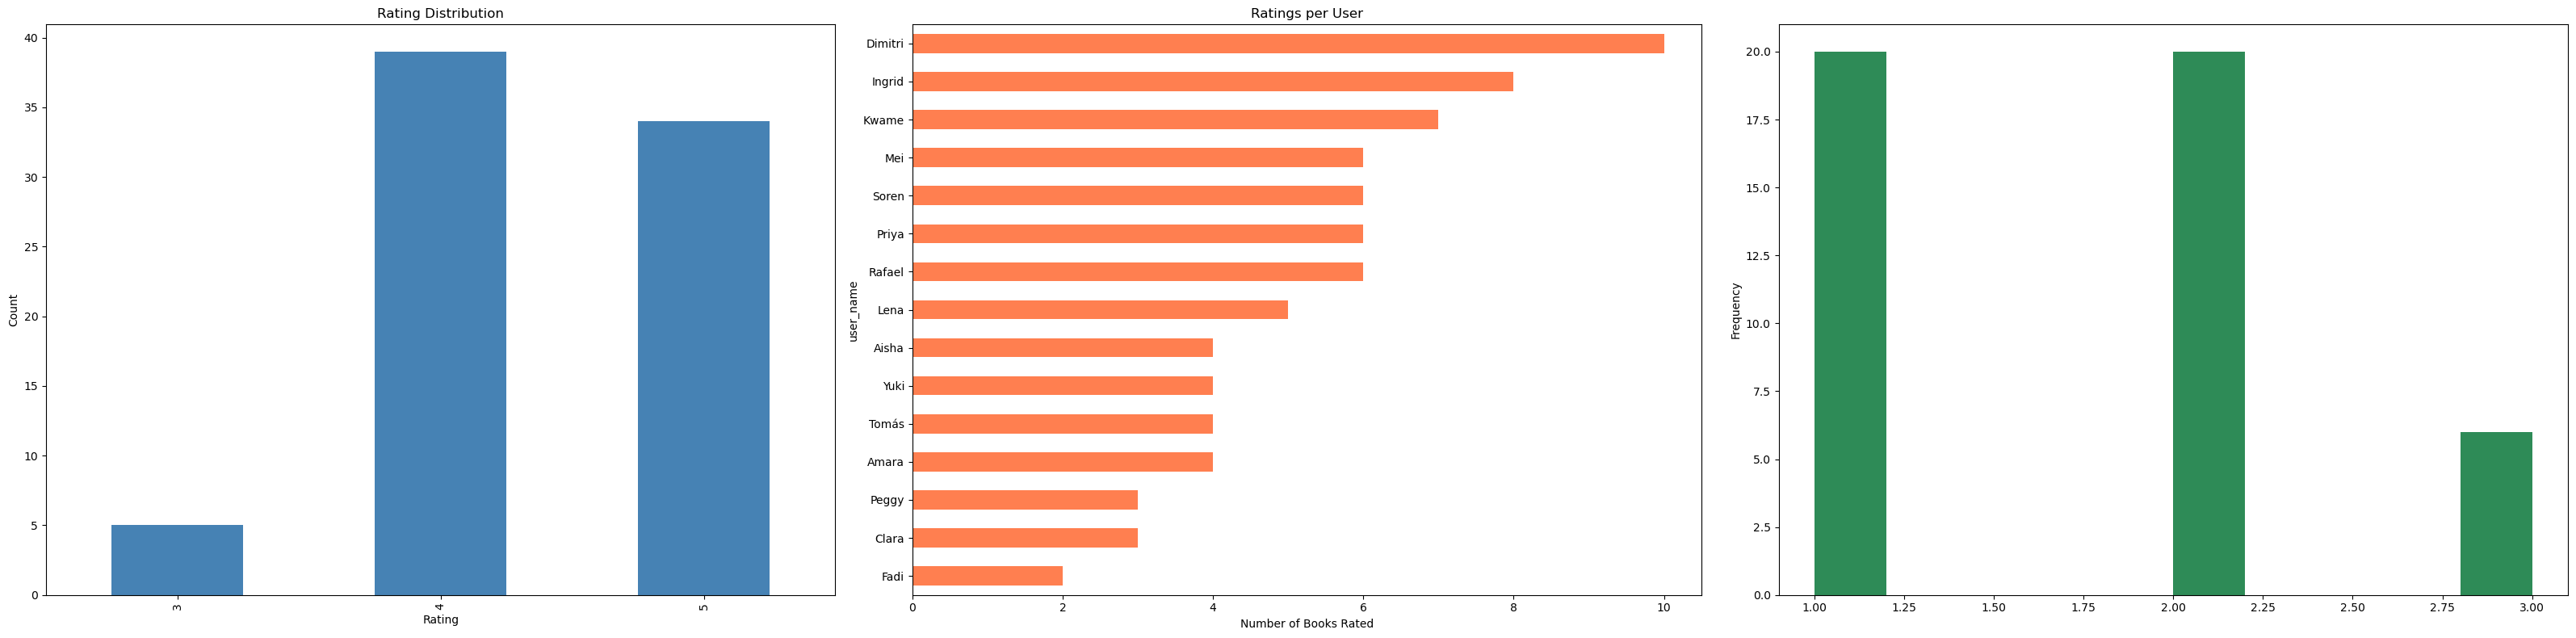

Users: 15 | Books rated: 46 | Total possible pairs: 690
Sparsity: 88.70% of the matrix is empty


In [69]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(32, 8))

# Rating distribution
ratings["rating"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Rating Distribution")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")

# Ratings per user
ratings.groupby("user_name").size().sort_values().plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Ratings per User")
axes[1].set_xlabel("Number of Books Rated")

# Ratings per book
ratings.groupby("book_id").size().sort_values().plot(kind="hist", ax=axes[2], color="seagreen")
axes[1].set_title("Ratings per User")
axes[1].set_xlabel("Number of Books Rated")

plt.tight_layout()
plt.show()

# Sparsity - how much of the matrix is empty?
n_users = ratings["user_id"].nunique() # number of unique users
n_books = ratings["book_id"].nunique() # number of unique rated books
sparsity = 1 - (len(ratings) / (n_users * n_books))

print(f"Users: {n_users} | Books rated: {n_books} | Total possible pairs: {n_users * n_books}")
print(f"Sparsity: {sparsity:.2%} of the matrix is empty")

## Build the User-Item Matrix

In [72]:
user_item_matrix = ratings.pivot_table(
    index="user_id",
    columns="book_id",
    values="adjusted_rating",
    fill_value=0
)

print("user-item-matrix shape:", user_item_matrix.shape)
user_item_matrix

user-item-matrix shape: (15, 46)


book_id,b001,b002,b003,b004,b005,b006,b007,b008,b009,b010,...,b041,b042,b043,b044,b045,b046,b047,b048,b049,b050
user_id,,,,,,,,,,,,,,,,,,,,,
u001,5.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u002,5.0,4.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u004,0.0,4.0,0.0,0.0,5.0,4.0,0.0,4.0,5.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u005,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u006,0.0,0.0,0.0,0.0,4.0,0.0,5.0,0.0,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u007,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u008,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Feature Engineering (Content-Based Signals)

In [90]:
# --- Genre overlap between user preferences and each book ---
# MultiLabelBinarizer turns lists like ["dystopia","sci-fi"] into binary columns

mlb = MultiLabelBinarizer()

# Encode book genres
book_genre_matrix = pd.DataFrame(
    mlb.fit_transform(books["genres"]),
    index=books["book_id"],
    columns=mlb.classes_
)

# Encode user preferred genres using the same vocabulary
user_genre_prefs = {}
for user in data["bookworms"]:
    fav = set(user["preferences"]["favorite_genres"])
    disliked = set(user["preferences"]["disliked_genres"])
    user_genre_prefs[user["user_id"]] = {"favorite": fav, "disliked": disliked}

def genre_overlap_score(user_id, book_id):
    """Returns a score: +1 per matching favorite genre, -0.5 per disliked genre."""
    if book_id not in book_genre_matrix.index:
        return 0
    book_genres = set(books.loc[books["book_id"] == book_id, "genres"].values[0])
    prefs = user_genre_prefs.get(user_id, {})
    overlap = len(book_genres & prefs.get("favorite", set()))
    dislike  = len(book_genres & prefs.get("disliked", set()))
    return overlap - (0.5 * dislike)

# --- Author affinity ---
# Has this user rated other books by the same author, and how highly?
book_author_map = books.set_index("book_id")["author_id"].to_dict()

def author_affinity_score(user_id, book_id):
    """Mean rating the user gave to other books by the same author."""
    target_author = book_author_map.get(book_id)
    if not target_author:
        return 0
    user_ratings = ratings[ratings["user_id"] == user_id]
    # Books by the same author this user has already rated
    same_author_books = [
        bid for bid in user_ratings["book_id"].values
        if book_author_map.get(bid) == target_author and bid != book_id
    ]
    if not same_author_books:
        return 0
    return user_ratings[user_ratings["book_id"].isin(same_author_books)]["rating"].mean()

# --- Wishlist signal ---
# Users have already expressed intent — treat this as implicit positive interest
wishlist_lookup = {}
for user in data["bookworms"]:
    wishlist_lookup[user["user_id"]] = {
        item["book_id"]: item["priority"] for item in user.get("wishlist", [])
    }

priority_score = {"high": 1.0, "medium": 0.5, "low": 0.2}

def wishlist_score(user_id, book_id):
    priority = wishlist_lookup.get(user_id, {}).get(book_id)
    return priority_score.get(priority, 0)

print("Feature engineering functions ready.")
print("Example — genre overlap for u001 on b005:", genre_overlap_score("u001", "b005"))
print("Example — author affinity for u002 on b014:", author_affinity_score("u002", "b014"))
print("Example — wishlist score for u001 on b014:", wishlist_score("u001", "b014"))

Feature engineering functions ready.
Example — genre overlap for u001 on b005: 1.0
Example — author affinity for u002 on b014: 4.5
Example — wishlist score for u001 on b014: 1.0


## Train/Test Split

In [93]:
train_df, test_df = train_test_split(
    ratings,
    test_size=0.2,
    random_state=42,
    stratify=ratings["user_id"]
)

print(f"Training ratings: {len(train_df)}")
print(f"Test ratings:     {len(test_df)}")

# build the training matrix only
train_matrix = train_df.pivot_table(
    index="user_id",
    columns="book_id",
    values="adjusted_rating",
    fill_value=0
)

train_matrix

Training ratings: 62
Test ratings:     16


book_id,b001,b002,b003,b004,b005,b006,b007,b008,b009,b010,...,b040,b042,b043,b044,b045,b046,b047,b048,b049,b050
user_id,,,,,,,,,,,,,,,,,,,,,
u001,5.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u002,5.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u004,0.0,4.0,0.0,0.0,5.0,4.0,0.0,4.0,5.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u006,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u007,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u008,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
